# 4. Feature Engineering 

This notebook creates a single merged dataset containing all Subsegment data (training and validation combined) and the Macro Indicators. We then globally compute leakage-free time-series features (Lags, Rolling stats, Hierarchy shares, Macro momentum).  

Computing them globally before pipeline cv ensures maximum speed and perfectly identical structures.

The engineered features can be categorized into the following buckets:

1. **Calendar Features**
   - *Month, Quarter, Is_Quarter_End*: Captures yearly seasonality and administrative reporting cycles.
2. **Lag Features `Lag_*`**
   - *L1, L2, L3, L6, L12, L24*: Past values of Orders and Revenue. Helps the model learn autocorrelations and exact historical anchoring.
3. **Rolling Statistics (`Rolling_Mean_*`, `Rolling_Std_*`)**
   - *3-month, 6-month, and 12-month windows*: Smooths out volatility to reveal the underlying sustained volume and variance over different time horizons.
4. **Trend/Momentum Features (`Trend_3_6`)**
   - *Ratio of Short-Term (3m) to Medium-Term (6m) Rolling Means*: Indicates if the recent trend is accelerating or not, compared to the historical baseline.
5. **Intermittency/Sparsity (`Zeros_6m`)**
   - *Count of zero-volume months in the last 6 periods*: Helps the model explicitly identify lumpy or intermittent demand patterns.
6. **Hierarchy Shares (`Share_of_Parent`)**
   - *Subsegment value / Parent Segment value*: Captures how much a specific subsegment contributes to the broader product line, helping the model learn portfolio cannibalization or dominance.
7. **Cross-Target Features (`Order_to_Rev_Ratio`)**
   - *L1_Orders / L1_Revenue*: Captures the pricing or volume-per-order dynamics to see if margin expansions/contractions predict future demand.
8. **Macroeconomic Momentum**
   - *Year-over-Year (YoY) or period-over-period changes for Macro indicators*: Exposes the model to the rate of change in the broader economy rather than just absolute macroeconomic values.



In [114]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 1. Load Data & Merge


In [115]:
data_dir = '../data/prepared'

# Load subsegment
train_df = pd.read_parquet(os.path.join(data_dir, 'training_subsegment.parquet'))
val_df = pd.read_parquet(os.path.join(data_dir, 'validation_subsegment.parquet'))

train_df['is_train'] = True
val_df['is_train'] = False

df = pd.concat([train_df, val_df], ignore_index=True)
df.sort_values(by=['TGL Business Subsegment', 'Anon Period'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Load macro
macro_df = pd.read_parquet(os.path.join(data_dir, 'macro_data_clean.parquet'))

# Merge Macro using Period as merging point
# It is completely leakage free to perform this join now
# Drop macro columns that already exist in df to avoid _x/_y duplicates
existing_cols = set(df.columns) - {'Anon Period'}
macro_cols_to_use = [c for c in macro_df.columns if c not in existing_cols or c == 'Period']
df = df.merge(macro_df[macro_cols_to_use], left_on='Anon Period', right_on='Period', how='left')
if 'Period' in df.columns:
    df.drop(columns=['Period'], inplace=True)

print("Merged shape:", df.shape)

Merged shape: (4952, 84)


## 2. Global Feature Engineering
Here we apply all the time-series operations. We encapsulate it into a set of Pandas functions.

In [116]:
# Save columns before feature engineering
base_cols_before_fe = df.columns.tolist()

In [117]:
def compute_leakage_free_features(df):
    target_cols = ["Orders cons. (anon)", "Revenue cons. (anon)"]
    subsegment_col = "TGL Business Subsegment"
    period_col = "Anon Period"
    eps = 1e-8
    
    # 1. Calendar
    month = ((df[period_col] - 1) % 12) + 1
    quarter = ((month - 1) // 3) + 1
    df["Month"] = month
    df["Quarter"] = quarter
    df["Month_sin"] = np.sin(2 * np.pi * month / 12.0)
    df["Month_cos"] = np.cos(2 * np.pi * month / 12.0)
    df["Quarter_sin"] = np.sin(2 * np.pi * quarter / 4.0)
    df["Quarter_cos"] = np.cos(2 * np.pi * quarter / 4.0)
    
    # Utilities
    def safe_divide(num, den):
        return num / np.where(np.abs(den) < eps, np.nan, den)
        
    def rolling_slope(arr):
        arr = np.asarray(arr, dtype=float)
        arr = arr[np.isfinite(arr)]
        n = len(arr)
        if n < 2: return np.nan
        t = np.arange(n, dtype=float)
        denom = np.sum((t - t.mean()) ** 2)
        if denom == 0: return np.nan
        return np.sum((t - t.mean()) * (arr - arr.mean())) / denom

    def months_since_nonzero(series):
        vals = series.to_numpy(dtype=float)
        out = np.full(len(vals), np.nan, dtype=float)
        last_idx = None
        for i, v in enumerate(vals):
            if np.isfinite(v) and v != 0: last_idx = i
            if last_idx is not None: out[i] = i - last_idx
        return pd.Series(out, index=series.index)

    # 2. Target Lags & Rolling
    for target in target_cols:
        grp = df.groupby(subsegment_col, sort=False)[target]
        for lag in [1, 2, 3, 6, 12, 24]:
            df[f"{target}_Lag_{lag}"] = grp.shift(lag)
            
        lag1_col = f"{target}_Lag_1"
        lag1_grp = df.groupby(subsegment_col, sort=False)[lag1_col]
        
        for w in [3, 6, 12]:
            df[f"{target}_Rolling_Mean_{w}"] = lag1_grp.transform(lambda s: s.rolling(w, min_periods=1).mean())
            df[f"{target}_Rolling_Std_{w}"] = lag1_grp.transform(lambda s: s.rolling(w, min_periods=2).std())
            df[f"{target}_Rolling_Min_{w}"] = lag1_grp.transform(lambda s: s.rolling(w, min_periods=1).min())
            df[f"{target}_Rolling_Max_{w}"] = lag1_grp.transform(lambda s: s.rolling(w, min_periods=1).max())
            df[f"{target}_Trend_Slope_{w}"] = lag1_grp.transform(lambda s: s.rolling(w, min_periods=2).apply(rolling_slope, raw=True))
            
        df[f"{target}_Momentum_3_12"] = df[f"{target}_Rolling_Mean_3"] - df[f"{target}_Rolling_Mean_12"]
        df[f"{target}_Momentum_6_12"] = df[f"{target}_Rolling_Mean_6"] - df[f"{target}_Rolling_Mean_12"]
        df[f"{target}_YoY_Diff"] = df[lag1_col] - df[f"{target}_Lag_12"]
        df[f"{target}_YoY_Ratio"] = safe_divide(df[lag1_col], df[f"{target}_Lag_12"])
        df[f"{target}_CV_12"] = safe_divide(df[f"{target}_Rolling_Std_12"], df[f"{target}_Rolling_Mean_12"])
        
        df[f"{target}_Months_Since_Last_Nonzero"] = df.groupby(subsegment_col, sort=False)[lag1_col].transform(months_since_nonzero)
        for w in [6, 12]:
            df[f"{target}_Nonzero_Count_{w}"] = lag1_grp.transform(lambda s: s.rolling(w, min_periods=1).apply(lambda x: np.sum(np.isfinite(x) & (x != 0)), raw=True))
            df[f"{target}_Zero_Share_{w}"] = lag1_grp.transform(lambda s: s.rolling(w, min_periods=1).apply(lambda x: np.mean(np.isfinite(x) & (x == 0)), raw=True))

    # 3. Hierarchy Features (aggregate-then-merge for correct period-level lags)
    parent_levels = [["TGL Business Unit"], ["TGL Business Unit", "TGL Business Segment"]]
    for target in target_cols:
        for level_cols in parent_levels:
            level_name = "__".join(level_cols)
            parent_keys = level_cols + [period_col]
            parent_current_col = f"{target}_Parent_Current_{level_name}"
            
            # 3a. Build unique parent-period series by aggregating children
            parent_ts = (
                df.groupby(parent_keys, dropna=False, as_index=False)[target]
                  .sum()
                  .sort_values(parent_keys)
                  .reset_index(drop=True)
            )
            parent_ts = parent_ts.rename(columns={target: parent_current_col})
            
            # 3b. Compute time-series features on deduplicated parent series
            grp = parent_ts.groupby(level_cols, dropna=False, sort=False)[parent_current_col]
            parent_ts[f"{target}_Parent_Lag_1_{level_name}"] = grp.shift(1)
            parent_ts[f"{target}_Parent_Lag_12_{level_name}"] = grp.shift(12)
            
            for w in [3, 6, 12]:
                parent_ts[f"{target}_Parent_Rolling_Mean_{w}_{level_name}"] = (
                    grp.transform(lambda s: s.shift(1).rolling(w, min_periods=1).mean())
                )
                parent_ts[f"{target}_Parent_Rolling_Std_{w}_{level_name}"] = (
                    grp.transform(lambda s: s.shift(1).rolling(w, min_periods=2).std())
                )
            
            parent_ts[f"{target}_Parent_YoY_Diff_{level_name}"] = (
                parent_ts[f"{target}_Parent_Lag_1_{level_name}"]
                - parent_ts[f"{target}_Parent_Lag_12_{level_name}"]
            )
            parent_ts[f"{target}_Parent_YoY_Ratio_{level_name}"] = safe_divide(
                parent_ts[f"{target}_Parent_Lag_1_{level_name}"],
                parent_ts[f"{target}_Parent_Lag_12_{level_name}"]
            )
            
            # 3c. Merge parent features back to child rows (many children -> one parent-period)
            feature_cols = [
                parent_current_col,
                f"{target}_Parent_Lag_1_{level_name}",
                f"{target}_Parent_Lag_12_{level_name}",
                f"{target}_Parent_YoY_Diff_{level_name}",
                f"{target}_Parent_YoY_Ratio_{level_name}",
            ] + [
                f"{target}_Parent_Rolling_Mean_{w}_{level_name}" for w in [3, 6, 12]
            ] + [
                f"{target}_Parent_Rolling_Std_{w}_{level_name}" for w in [3, 6, 12]
            ]
            df = df.merge(
                parent_ts[parent_keys + feature_cols],
                on=parent_keys, how="left", validate="many_to_one",
            )
            
            # 3d. Child share of parent (using lagged values to avoid leakage)
            df[f"{target}_Share_of_Parent_Lag_1_{level_name}"] = safe_divide(df[f"{target}_Lag_1"], df[f"{target}_Parent_Lag_1_{level_name}"])
            df[f"{target}_Share_of_Parent_Lag_12_{level_name}"] = safe_divide(df[f"{target}_Lag_12"], df[f"{target}_Parent_Lag_12_{level_name}"])
            df[f"{target}_Share_of_Parent_YoY_Diff_{level_name}"] = df[f"{target}_Share_of_Parent_Lag_1_{level_name}"] - df[f"{target}_Share_of_Parent_Lag_12_{level_name}"]
            
            # Drop internal column that could cause leakage
            df.drop(columns=[parent_current_col], inplace=True)
            
    # 4. Cross Features
    df["ASP_Lag_1"] = safe_divide(df["Revenue cons. (anon)_Lag_1"], df["Orders cons. (anon)_Lag_1"])
    df["ASP_Lag_12"] = safe_divide(df["Revenue cons. (anon)_Lag_12"], df["Orders cons. (anon)_Lag_12"])
    df["ASP_YoY_Diff"] = df["ASP_Lag_1"] - df["ASP_Lag_12"]
    df["ASP_Rolling_Mean_3"] = safe_divide(df["Revenue cons. (anon)_Rolling_Mean_3"], df["Orders cons. (anon)_Rolling_Mean_3"])
    df["ASP_Rolling_Mean_12"] = safe_divide(df["Revenue cons. (anon)_Rolling_Mean_12"], df["Orders cons. (anon)_Rolling_Mean_12"])
    df["Revenue_vs_Orders_Momentum_3_12"] = df["Revenue cons. (anon)_Momentum_3_12"] - df["Orders cons. (anon)_Momentum_3_12"]

    # 5. Macro Features
    key_macro_cols = [c for c in macro_df.columns if c != 'Period' and ('GDP' in c or 'Inflation' in c)]
    available_macros = [c for c in key_macro_cols if c in df.columns]

    macro_cols_needed = [c for c in available_macros if c in macro_df.columns]
    period_macro = (
    macro_df[['Period'] + macro_cols_needed]
        .copy()
        .rename(columns={'Period': period_col})
        .sort_values(period_col)
        .reset_index(drop=True)
    )
    for col in available_macros:
        for lag in [1, 3, 6, 12]:
            period_macro[f"{col}_Lag_{lag}"] = period_macro[col].shift(lag)
        lag1_series = period_macro[f"{col}_Lag_1"]
        for w in [3, 12]:
            period_macro[f"{col}_Rolling_Mean_{w}"] = lag1_series.rolling(w, min_periods=1).mean()
            period_macro[f"{col}_Rolling_Std_{w}"] = lag1_series.rolling(w, min_periods=2).std()
        
        period_macro[f"{col}_YoY_Diff"] = lag1_series - period_macro[f"{col}_Lag_12"]
        period_macro[f"{col}_YoY_Ratio"] = safe_divide(lag1_series, period_macro[f"{col}_Lag_12"])
        period_macro[f"{col}_Momentum_3_12"] = period_macro[f"{col}_Rolling_Mean_3"] - period_macro[f"{col}_Rolling_Mean_12"]
        period_macro[f"{col}_Anomaly_12"] = safe_divide(lag1_series - period_macro[f"{col}_Rolling_Mean_12"], period_macro[f"{col}_Rolling_Std_12"])
        
    macro_feat_cols = [c for c in period_macro.columns if c != period_col and c not in available_macros]
    df = df.merge(period_macro[[period_col] + macro_feat_cols], on=period_col, how="left", validate="many_to_one")

    return df

df = compute_leakage_free_features(df)
engineered_cols = [c for c in df.columns if c not in base_cols_before_fe]

print("Features computed successfully.")
print("Total columns:", len(df.columns))
print("Engineered columns:", len(engineered_cols))

Features computed successfully.
Total columns: 666
Engineered columns: 582


## 3. EDA 

In [118]:
# Split engineered features by family
feature_groups = {
    "calendar": [c for c in engineered_cols if any(k in c for k in ["Month", "Quarter", "_sin", "_cos"])],
    "lags": [c for c in engineered_cols if "_Lag_" in c and "Parent" not in c],
    "rolling": [c for c in engineered_cols if "Rolling_" in c and "Parent" not in c],
    "trend_momentum": [c for c in engineered_cols if any(k in c for k in ["Trend_Slope", "Momentum", "YoY", "CV_"])],
    "intermittency": [c for c in engineered_cols if any(k in c for k in ["Months_Since_Last_Nonzero", "Nonzero_Count", "Zero_Share"])],
    "hierarchy": [c for c in engineered_cols if "Parent" in c or "Share_of_Parent" in c],
    "cross": [c for c in engineered_cols if any(k in c for k in ["ASP_", "Revenue_vs_Orders"])],
}

feature_group_summary = pd.DataFrame({
    "feature_group": list(feature_groups.keys()),
    "n_features": [len(v) for v in feature_groups.values()]
}).sort_values("n_features", ascending=False)

display(feature_group_summary)

# print first few names from each family
for group, cols in feature_groups.items():
    print(f"\n{group.upper()} ({len(cols)} features)")
    print(cols[:10])

,feature_group,n_features
2,rolling,178
1,lags,166
3,trend_momentum,144
5,hierarchy,52
4,intermittency,10
0,calendar,8
6,cross,6



CALENDAR (8 features)
['Month', 'Quarter', 'Month_sin', 'Month_cos', 'Quarter_sin', 'Quarter_cos', 'Orders cons. (anon)_Months_Since_Last_Nonzero', 'Revenue cons. (anon)_Months_Since_Last_Nonzero']

LAGS (166 features)
['Orders cons. (anon)_Lag_1', 'Orders cons. (anon)_Lag_2', 'Orders cons. (anon)_Lag_3', 'Orders cons. (anon)_Lag_6', 'Orders cons. (anon)_Lag_12', 'Orders cons. (anon)_Lag_24', 'Revenue cons. (anon)_Lag_1', 'Revenue cons. (anon)_Lag_2', 'Revenue cons. (anon)_Lag_3', 'Revenue cons. (anon)_Lag_6']

ROLLING (178 features)
['Orders cons. (anon)_Rolling_Mean_3', 'Orders cons. (anon)_Rolling_Std_3', 'Orders cons. (anon)_Rolling_Min_3', 'Orders cons. (anon)_Rolling_Max_3', 'Orders cons. (anon)_Rolling_Mean_6', 'Orders cons. (anon)_Rolling_Std_6', 'Orders cons. (anon)_Rolling_Min_6', 'Orders cons. (anon)_Rolling_Max_6', 'Orders cons. (anon)_Rolling_Mean_12', 'Orders cons. (anon)_Rolling_Std_12']

TREND_MOMENTUM (144 features)
['Orders cons. (anon)_Trend_Slope_3', 'Orders cons. 

### 3.1. Missingness and Basic Summary
High missingness is expected for long lags like 12 and 24, especially at the beginning of each subsegment series.

In [119]:
# Missingness summary for engineered features
missing_summary = (
    df[engineered_cols]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_pct")
    .reset_index()
    .rename(columns={"index": "feature"})
)

display(missing_summary.head(20))

# Summary stats for engineered numeric features
eng_num_cols = df[engineered_cols].select_dtypes(include=np.number).columns.tolist()

summary_stats = (
    df[eng_num_cols]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .T
    .reset_index()
    .rename(columns={"index": "feature"})
)

display(summary_stats.head(20))

,feature,missing_pct
0,Orders cons. (anon)_Lag_24,0.560985
1,Revenue cons. (anon)_Lag_24,0.560985
2,ASP_YoY_Diff,0.447698
3,Orders cons. (anon)_YoY_Ratio,0.443457
4,Revenue cons. (anon)_YoY_Ratio,0.435582
5,Orders cons. (anon)_Share_of_Parent_YoY_Diff_T...,0.428716
6,Revenue cons. (anon)_Share_of_Parent_YoY_Diff_...,0.422456
7,Revenue cons. (anon)_Share_of_Parent_YoY_Diff_...,0.410541
8,Orders cons. (anon)_Share_of_Parent_YoY_Diff_T...,0.410541
9,Revenue cons. (anon)_YoY_Diff,0.410339


,feature,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
0,Month,4952.0,6.507876e+00,3.451710e+00,1.0,1.000000e+00,1.0,4.000000e+00,6.000000e+00,1.000000e+01,1.200000e+01,1.200000e+01,1.200000e+01
1,Quarter,4952.0,2.500808e+00,1.117605e+00,1.0,1.000000e+00,1.0,2.000000e+00,2.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00
2,Month_sin,4952.0,1.364768e-03,7.072483e-01,-1.0,-1.000000e+00,-1.0,-5.000000e-01,1.224647e-16,8.660254e-01,1.000000e+00,1.000000e+00,1.000000e+00
3,Month_cos,4952.0,-6.256212e-04,7.071065e-01,-1.0,-1.000000e+00,-1.0,-5.000000e-01,-1.836970e-16,5.000000e-01,1.000000e+00,1.000000e+00,1.000000e+00
4,Quarter_sin,4952.0,-4.038772e-04,7.063207e-01,-1.0,-1.000000e+00,-1.0,-2.449294e-16,1.224647e-16,1.224647e-16,1.000000e+00,1.000000e+00,1.000000e+00
5,Quarter_cos,4952.0,-8.077544e-04,7.080340e-01,-1.0,-1.000000e+00,-1.0,-1.000000e+00,-1.836970e-16,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
6,Orders cons. (anon)_Lag_1,4226.0,4.018077e+07,7.047683e+07,-56101878.0,-6.855650e+04,0.0,8.964102e+05,9.354446e+06,4.335715e+07,1.983544e+08,3.302296e+08,5.950944e+08
7,Orders cons. (anon)_Lag_2,4214.0,4.029504e+07,7.054453e+07,-56101878.0,-6.869018e+04,0.0,9.219658e+05,9.417352e+06,4.354722e+07,1.984925e+08,3.309952e+08,5.950944e+08
8,Orders cons. (anon)_Lag_3,4201.0,4.041948e+07,7.061808e+07,-56101878.0,-6.883500e+04,0.0,9.399190e+05,9.523251e+06,4.377293e+07,1.985518e+08,3.318247e+08,5.950944e+08
9,Orders cons. (anon)_Lag_6,4174.0,4.068072e+07,7.077117e+07,-56101878.0,-7.535739e+04,0.0,9.851278e+05,9.777426e+06,4.443280e+07,1.993131e+08,3.322560e+08,5.950944e+08


### 3.2. Relationship with Targets on Train Only

In [120]:
target_cols = ["Orders cons. (anon)", "Revenue cons. (anon)"]

df_train_only = df[df["is_train"] == True].copy()

corr_tables = {}

for target in target_cols:
    corr_series = (
        df_train_only[eng_num_cols + [target]]
        .corr(numeric_only=True)[target]
        .drop(target)
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )
    corr_tables[target] = corr_series.reset_index().rename(
        columns={"index": "feature", target: "correlation"}
    )
    
    print(f"\nTop engineered features most correlated with {target}")
    display(corr_tables[target].head(15))


Top engineered features most correlated with Orders cons. (anon)


,feature,correlation
0,Orders cons. (anon)_Rolling_Mean_6,0.954507
1,Orders cons. (anon)_Rolling_Mean_3,0.954429
2,Orders cons. (anon)_Rolling_Mean_12,0.953919
3,Orders cons. (anon)_Rolling_Min_3,0.943709
4,Orders cons. (anon)_Lag_3,0.942516
5,Revenue cons. (anon)_Rolling_Mean_3,0.939809
6,Revenue cons. (anon)_Lag_3,0.937961
7,Revenue cons. (anon)_Rolling_Mean_6,0.936980
8,Revenue cons. (anon)_Rolling_Max_3,0.935632
9,Orders cons. (anon)_Rolling_Min_6,0.933489



Top engineered features most correlated with Revenue cons. (anon)


,feature,correlation
0,Revenue cons. (anon)_Rolling_Mean_3,0.985365
1,Revenue cons. (anon)_Rolling_Mean_6,0.984498
2,Revenue cons. (anon)_Rolling_Min_3,0.983426
3,Revenue cons. (anon)_Lag_3,0.982105
4,Revenue cons. (anon)_Rolling_Mean_12,0.982032
5,Revenue cons. (anon)_Rolling_Min_6,0.979281
6,Revenue cons. (anon)_Lag_6,0.977133
7,Orders cons. (anon)_Rolling_Mean_12,0.975166
8,Revenue cons. (anon)_Rolling_Max_3,0.974884
9,Revenue cons. (anon)_Lag_1,0.974556


### 3.3. Visualize Top Features Against the Target (both `Orders` and `Revenue`)

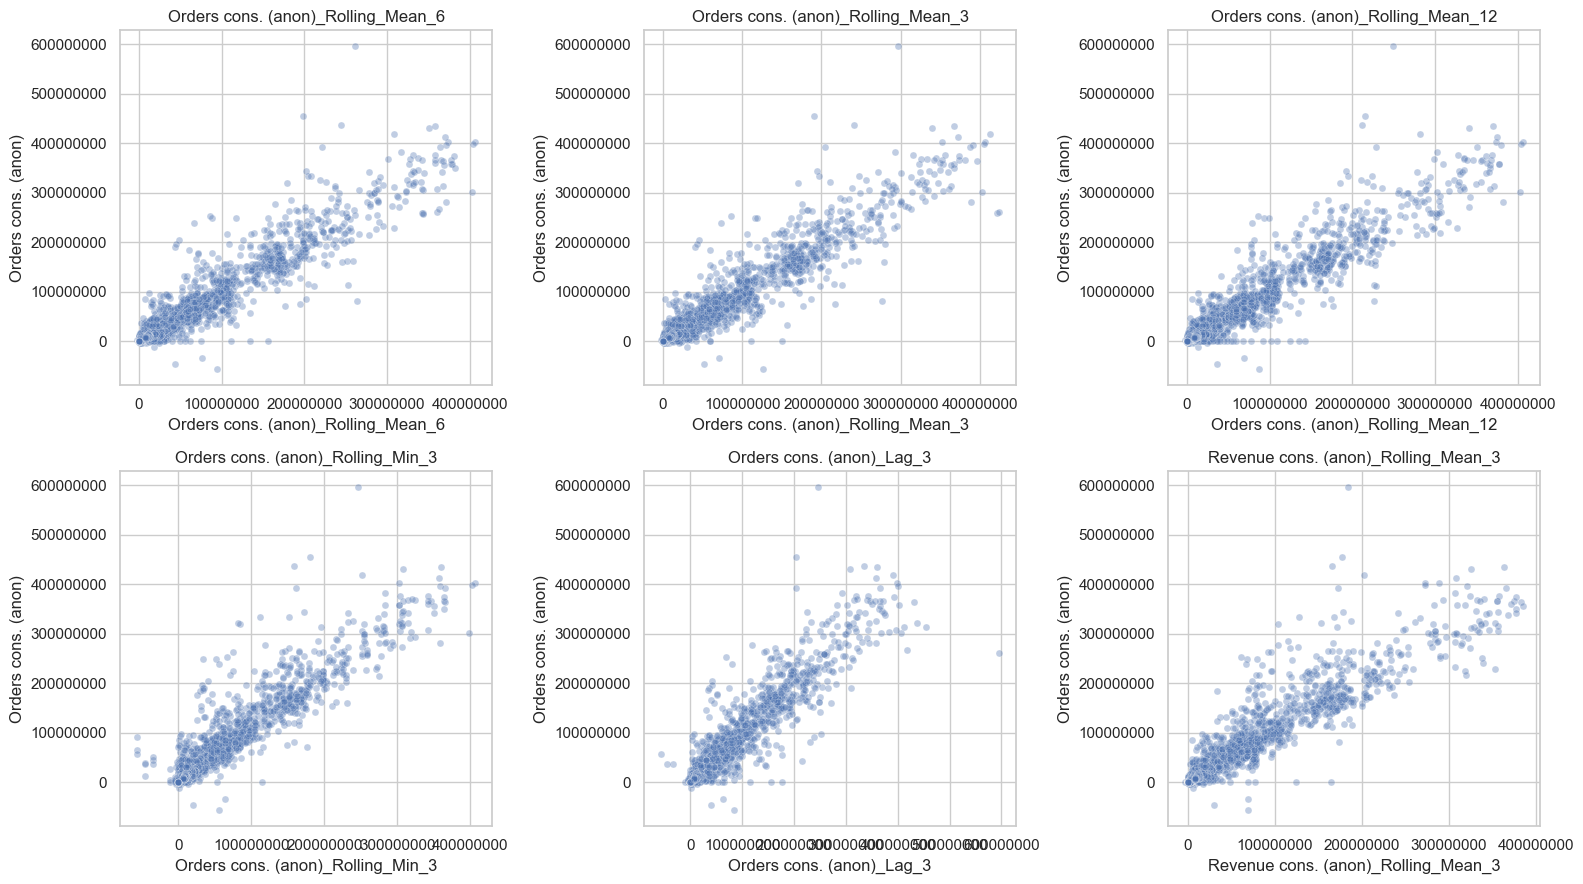

In [121]:
# Pick top 6 features by absolute correlation with Orders
top_orders_feats = corr_tables["Orders cons. (anon)"]["feature"].head(6).tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, feat in zip(axes, top_orders_feats):
    sns.scatterplot(
        data=df_train_only,
        x=feat,
        y="Orders cons. (anon)",
        alpha=0.35,
        s=25,
        ax=ax
    )
    ax.set_title(feat)
    ax.ticklabel_format(style='plain', axis='both')

plt.tight_layout()
plt.show()

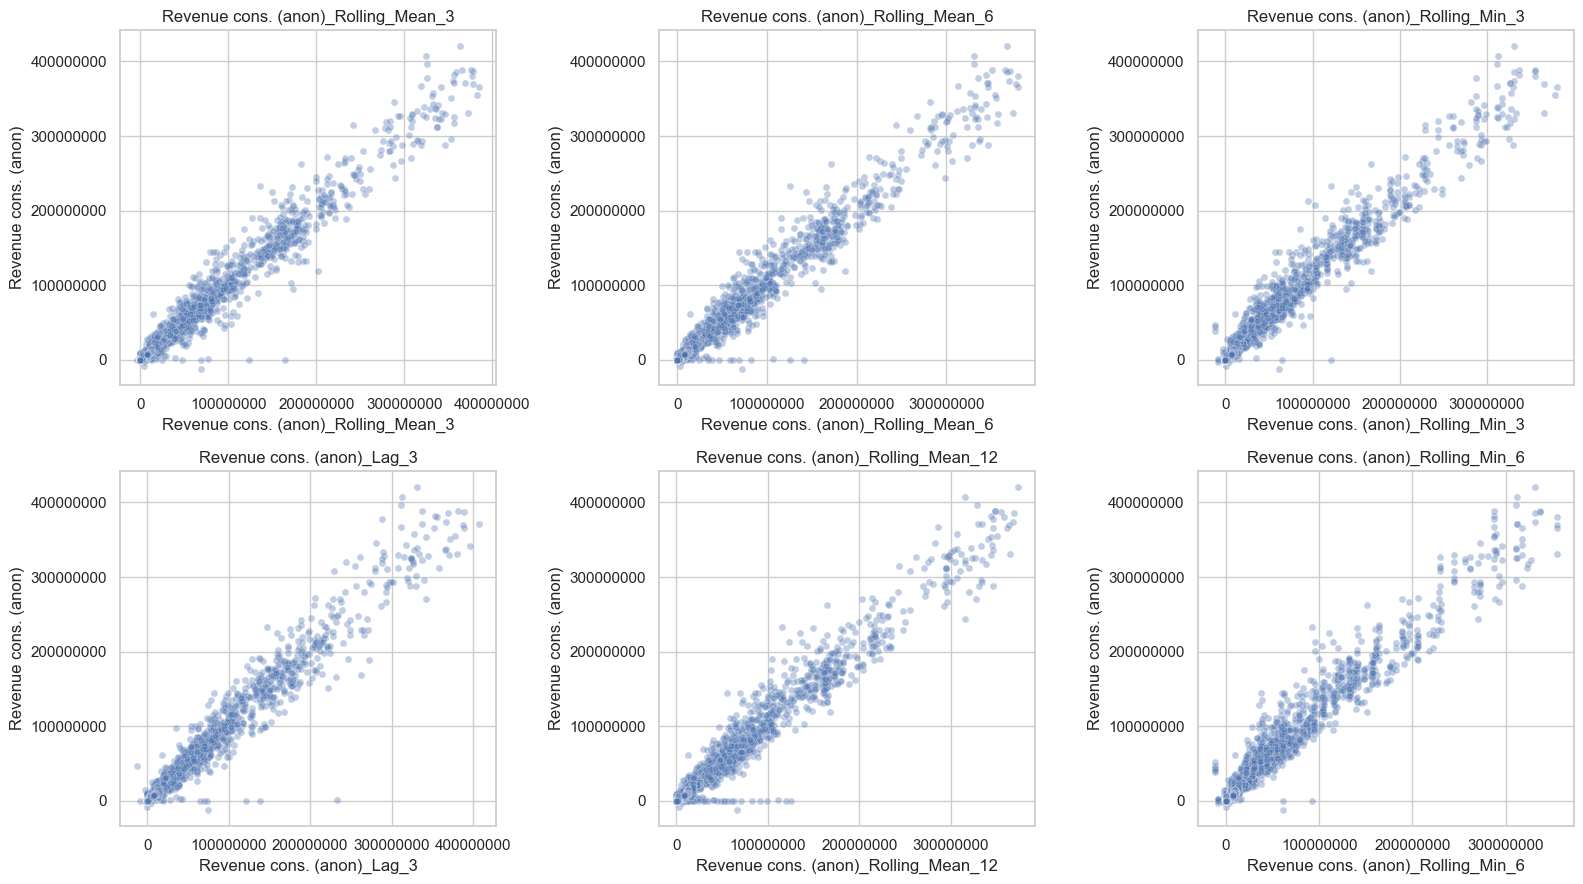

In [122]:
top_revenue_feats = corr_tables["Revenue cons. (anon)"]["feature"].head(6).tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, feat in zip(axes, top_revenue_feats):
    sns.scatterplot(
        data=df_train_only,
        x=feat,
        y="Revenue cons. (anon)",
        alpha=0.35,
        s=25,
        ax=ax
    )
    ax.set_title(feat)
    ax.ticklabel_format(style='plain', axis='both')

plt.tight_layout()
plt.show()

Lags / Rolling means are positively correlated with the target variables, as expected.

> **`Orders < 0` and `Revenue < 0` still have to be addressed!**

### 3.4. Compare Train vs Validation Drift for Engineered Features

In [123]:
# Train vs validation drift using standardized mean difference
df_train_only = df[df["is_train"] == True].copy()
df_val_only = df[df["is_train"] == False].copy()

drift_rows = []

for col in eng_num_cols:
    x_tr = df_train_only[col]
    x_va = df_val_only[col]
    
    mean_tr = x_tr.mean()
    mean_va = x_va.mean()
    std_tr = x_tr.std()
    
    smd = np.nan if pd.isna(std_tr) or std_tr == 0 else (mean_va - mean_tr) / std_tr
    
    drift_rows.append({
        "feature": col,
        "train_mean": mean_tr,
        "val_mean": mean_va,
        "train_std": std_tr,
        "std_mean_diff": smd,
        "train_missing_pct": x_tr.isna().mean(),
        "val_missing_pct": x_va.isna().mean(),
    })

drift_df = pd.DataFrame(drift_rows)
drift_df["abs_std_mean_diff"] = drift_df["std_mean_diff"].abs()
drift_df = drift_df.sort_values("abs_std_mean_diff", ascending=False)

display(drift_df.head(20))

,feature,train_mean,val_mean,train_std,std_mean_diff,train_missing_pct,val_missing_pct,abs_std_mean_diff
103,Revenue cons. (anon)_Parent_Rolling_Std_12_TGL...,1.338115e+08,4.707161e+08,4.999373e+07,6.738935,0.043899,0.000000,6.738935
77,Orders cons. (anon)_Parent_Rolling_Std_12_TGL ...,1.426745e+08,5.210291e+08,5.673859e+07,6.668382,0.043899,0.000000,6.668382
76,Orders cons. (anon)_Parent_Rolling_Std_6_TGL B...,1.427269e+08,5.876314e+08,6.804712e+07,6.538181,0.043899,0.000000,6.538181
102,Revenue cons. (anon)_Parent_Rolling_Std_6_TGL ...,1.333562e+08,5.264745e+08,6.135190e+07,6.407597,0.043899,0.000000,6.407597
96,Revenue cons. (anon)_Parent_YoY_Diff_TGL Busin...,9.702286e+07,-9.843741e+08,2.420972e+08,-4.466789,0.261034,0.000000,4.466789
70,Orders cons. (anon)_Parent_YoY_Diff_TGL Busine...,6.822548e+07,-9.991943e+08,2.631302e+08,-4.056623,0.261034,0.000000,4.056623
109,Revenue cons. (anon)_Parent_YoY_Diff_TGL Busin...,4.034610e+07,-3.504801e+08,1.223794e+08,-3.193561,0.271654,0.005594,3.193561
301,Germany_Inflation_Rate_Rolling_Std_12,1.331271e+00,4.439908e-01,2.871507e-01,-3.089946,0.000000,0.000000,3.089946
283,Germany_GDP_from_Manufacturing_Lag_3,1.742415e+02,1.659374e+02,2.857315e+00,-2.906228,0.000000,0.000000,2.906228
115,Revenue cons. (anon)_Parent_Rolling_Std_6_TGL ...,4.940640e+07,1.875483e+08,4.825341e+07,2.862841,0.046495,0.000000,2.862841


### 3.5. Distribution Plots for the Most Important Engineered Features

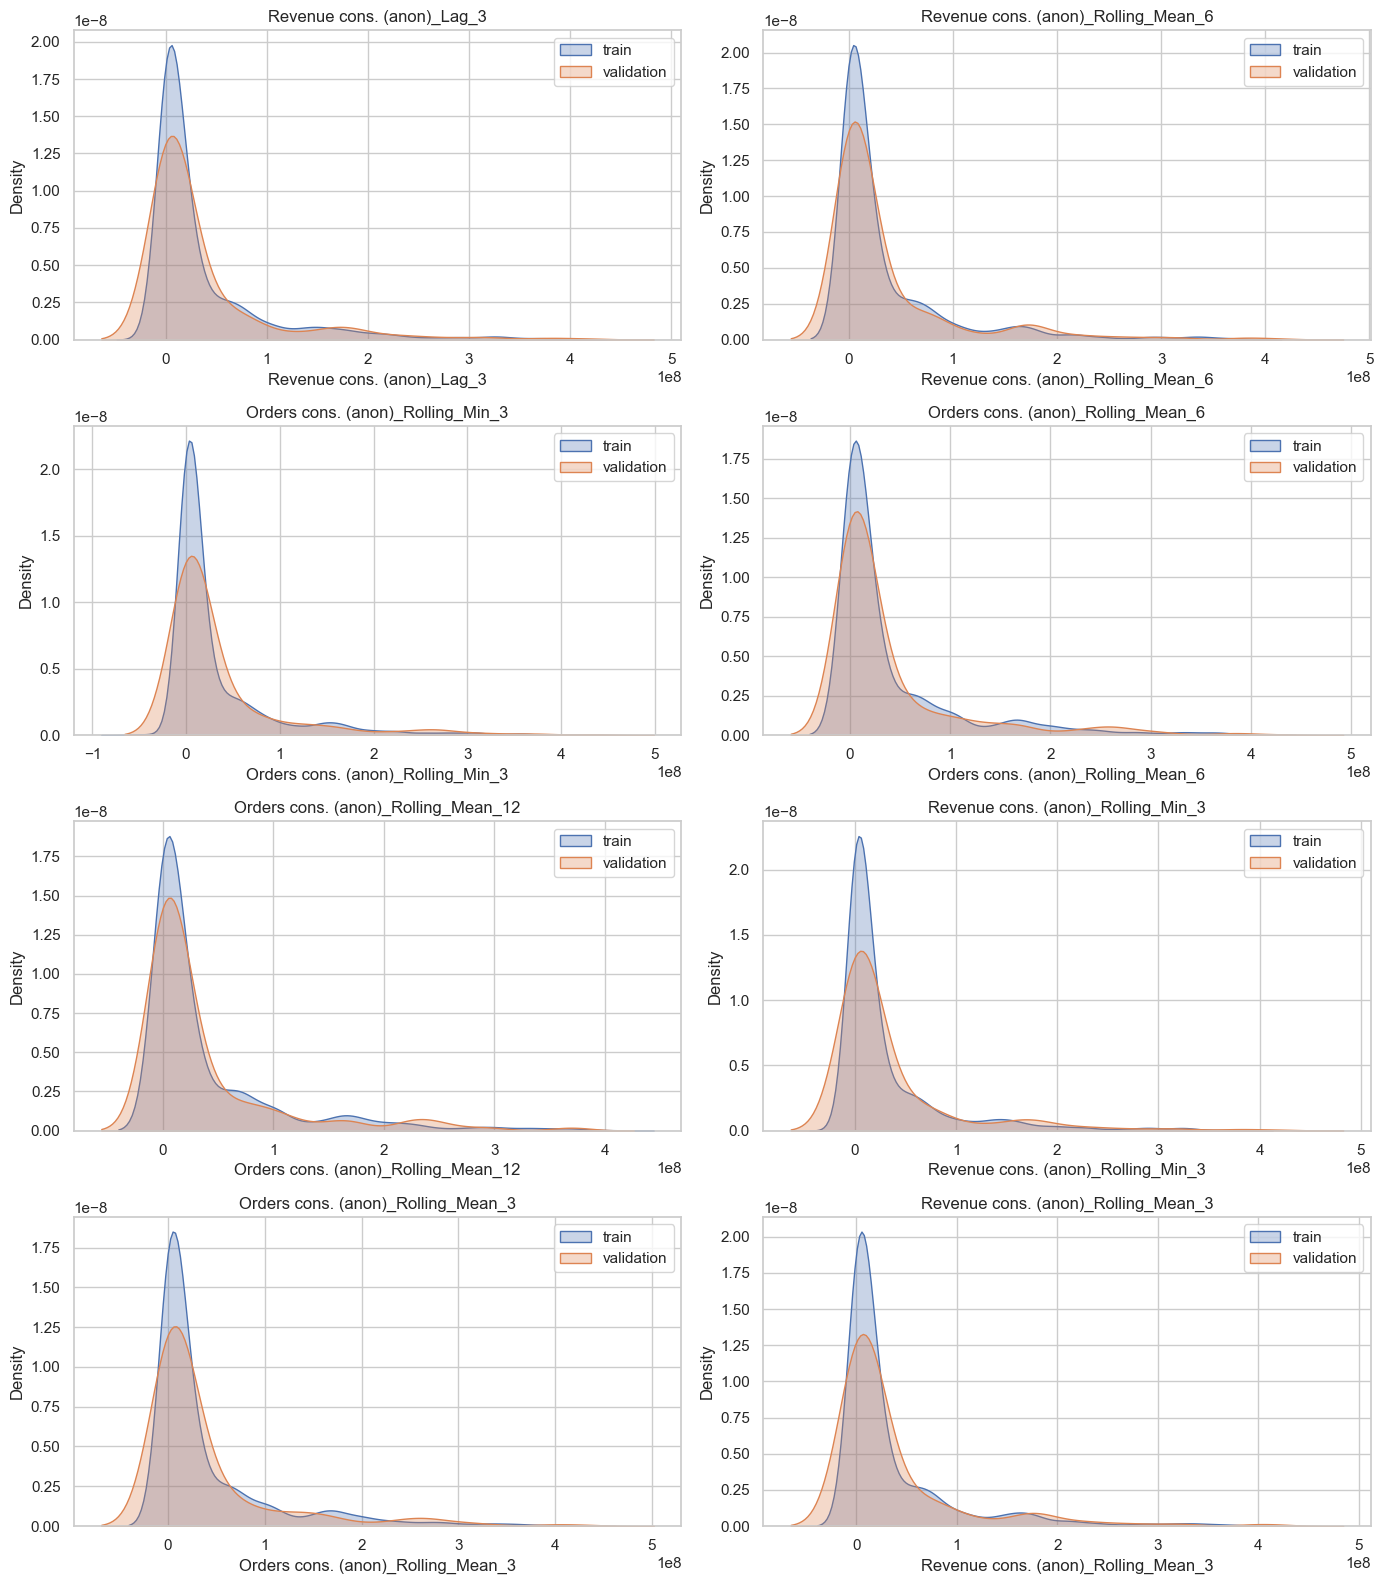

In [124]:
# Use top correlated features for compact plotting
top_plot_feats = list(set(
    corr_tables["Orders cons. (anon)"]["feature"].head(4).tolist() +
    corr_tables["Revenue cons. (anon)"]["feature"].head(4).tolist()
))

n = len(top_plot_feats)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, feat in zip(axes, top_plot_feats):
    sns.kdeplot(df_train_only[feat], label="train", fill=True, alpha=0.3, ax=ax)
    sns.kdeplot(df_val_only[feat], label="validation", fill=True, alpha=0.3, ax=ax)
    ax.set_title(feat)
    ax.legend()

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### 3.6. Small Time-Series Sanity Check for One Subsegment

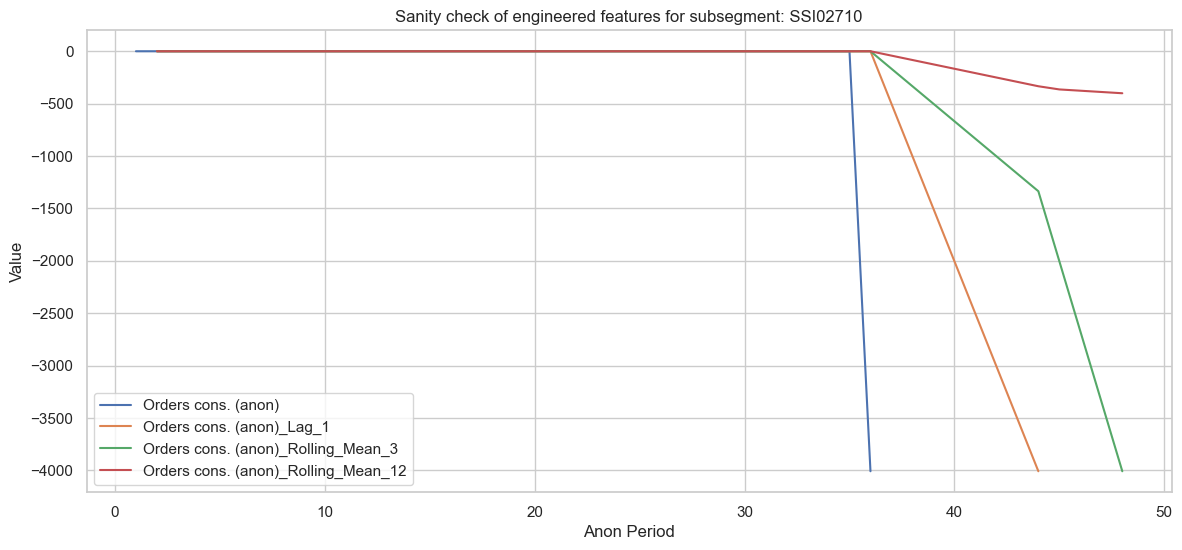

In [125]:
example_subsegment = df["TGL Business Subsegment"].dropna().iloc[0]

plot_cols = [
    "Orders cons. (anon)",
    "Orders cons. (anon)_Lag_1",
    "Orders cons. (anon)_Rolling_Mean_3",
    "Orders cons. (anon)_Rolling_Mean_12",
]

tmp = (
    df[df["TGL Business Subsegment"] == example_subsegment]
    .sort_values("Anon Period")
    [[ "Anon Period" ] + plot_cols]
    .copy()
)

plt.figure(figsize=(14, 6))
for col in plot_cols:
    plt.plot(tmp["Anon Period"], tmp[col], label=col)

plt.title(f"Sanity check of engineered features for subsegment: {example_subsegment}")
plt.xlabel("Anon Period")
plt.ylabel("Value")
plt.legend()
plt.show()

### 3.7. Feature Collinearity Heatmap

To ensure our linear models or feature selection techniques don't suffer excessively from multicollinearity, let's visualize the correlation among the top 15 engineered features themselves.

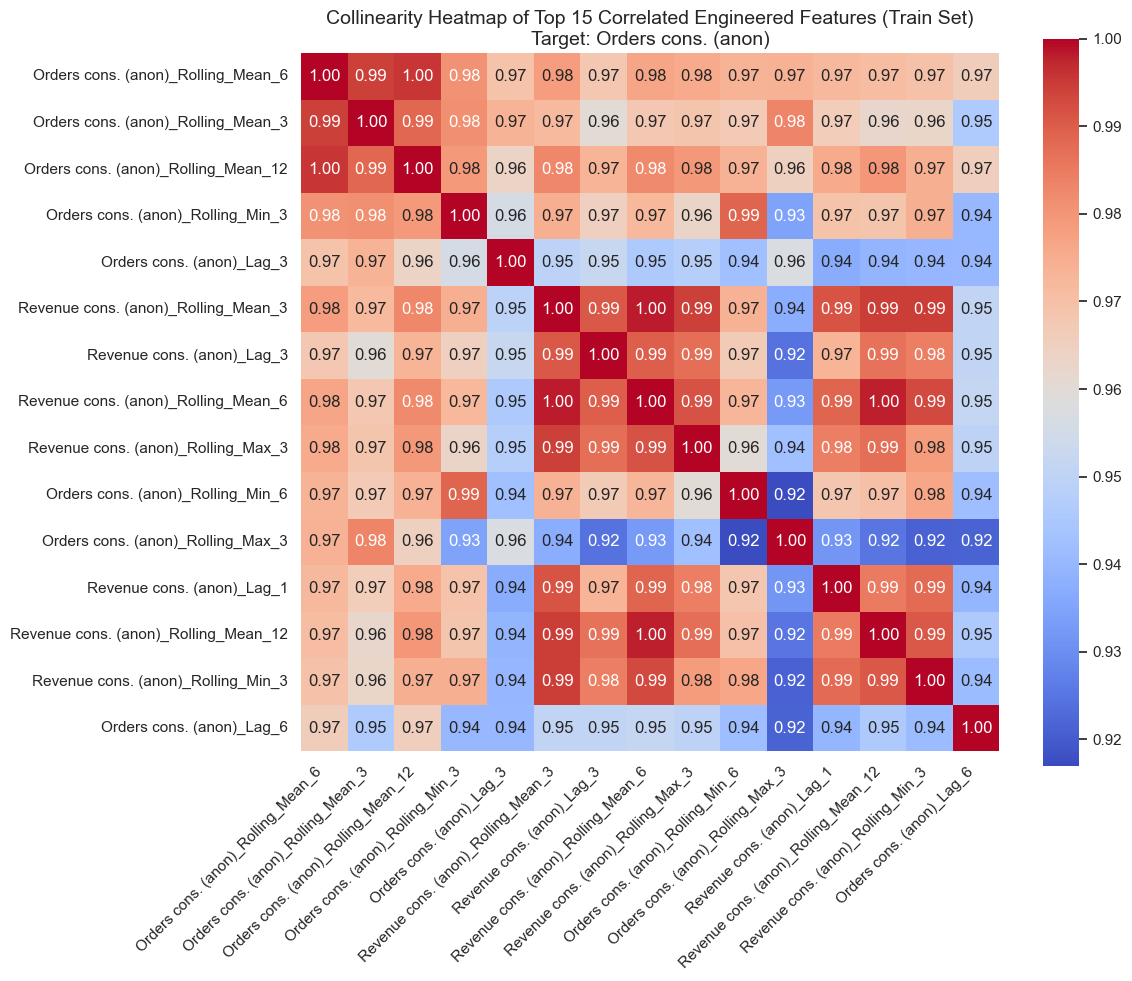

In [126]:
# Extract top 15 feature names for the primary target
top_15_features = corr_tables[target_cols[0]]['feature'].head(15).tolist()

# Compute correlation matrix for these features on the training set
feat_corr_matrix = df_train_only[top_15_features].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(feat_corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True)
plt.title(f'Collinearity Heatmap of Top 15 Correlated Engineered Features (Train Set)\nTarget: {target_cols[0]}', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.8. Distribution of Top 5 Engineered Features

Understanding the distribution of top features can help decide if scaling or power transformations are needed before modeling.

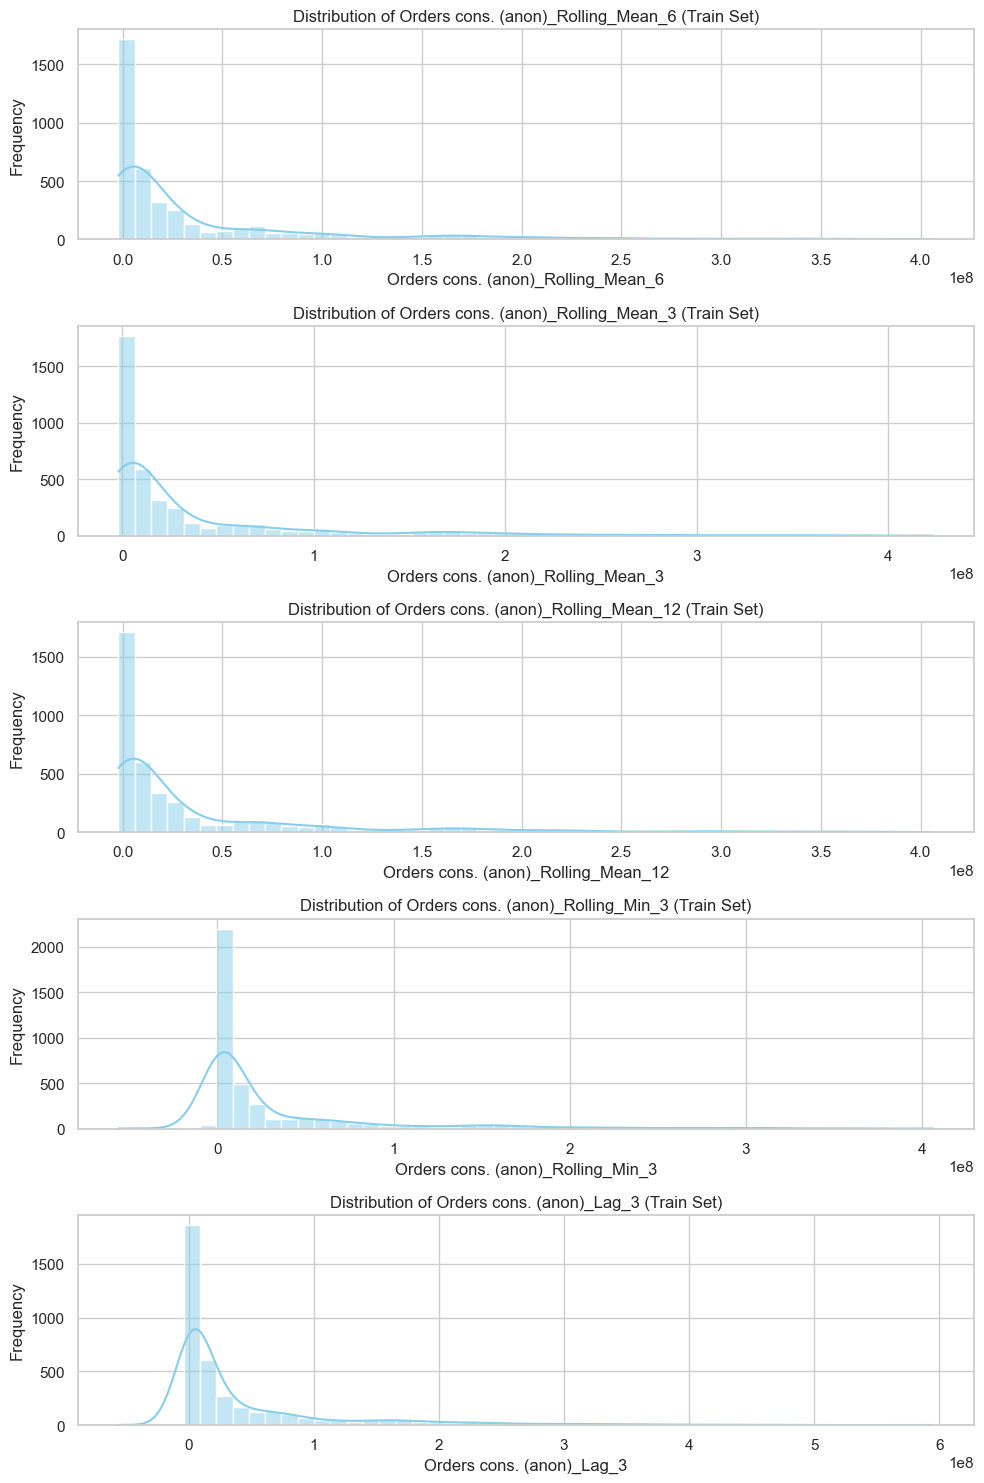

In [127]:
# Plot distributions for the top 5 engineered features
top_5_features = top_15_features[:5]

fig, axes = plt.subplots(nrows=len(top_5_features), ncols=1, figsize=(10, 3 * len(top_5_features)))

for idx, feature in enumerate(top_5_features):
    sns.histplot(df_train_only[feature].dropna(), kde=True, ax=axes[idx], color='skyblue', bins=50)
    axes[idx].set_title(f'Distribution of {feature} (Train Set)', fontsize=12)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 3.9. Time-Series Tracking: Target vs. Top Feature

Scatter plots show overall correlation, but visualizing how the lagged or rolling feature tracks the actual target over time for a high-volume subsegment provides stronger intuition for its predictive power.

Plotting Time-Series for the most frequent subsegment: SSI0278002


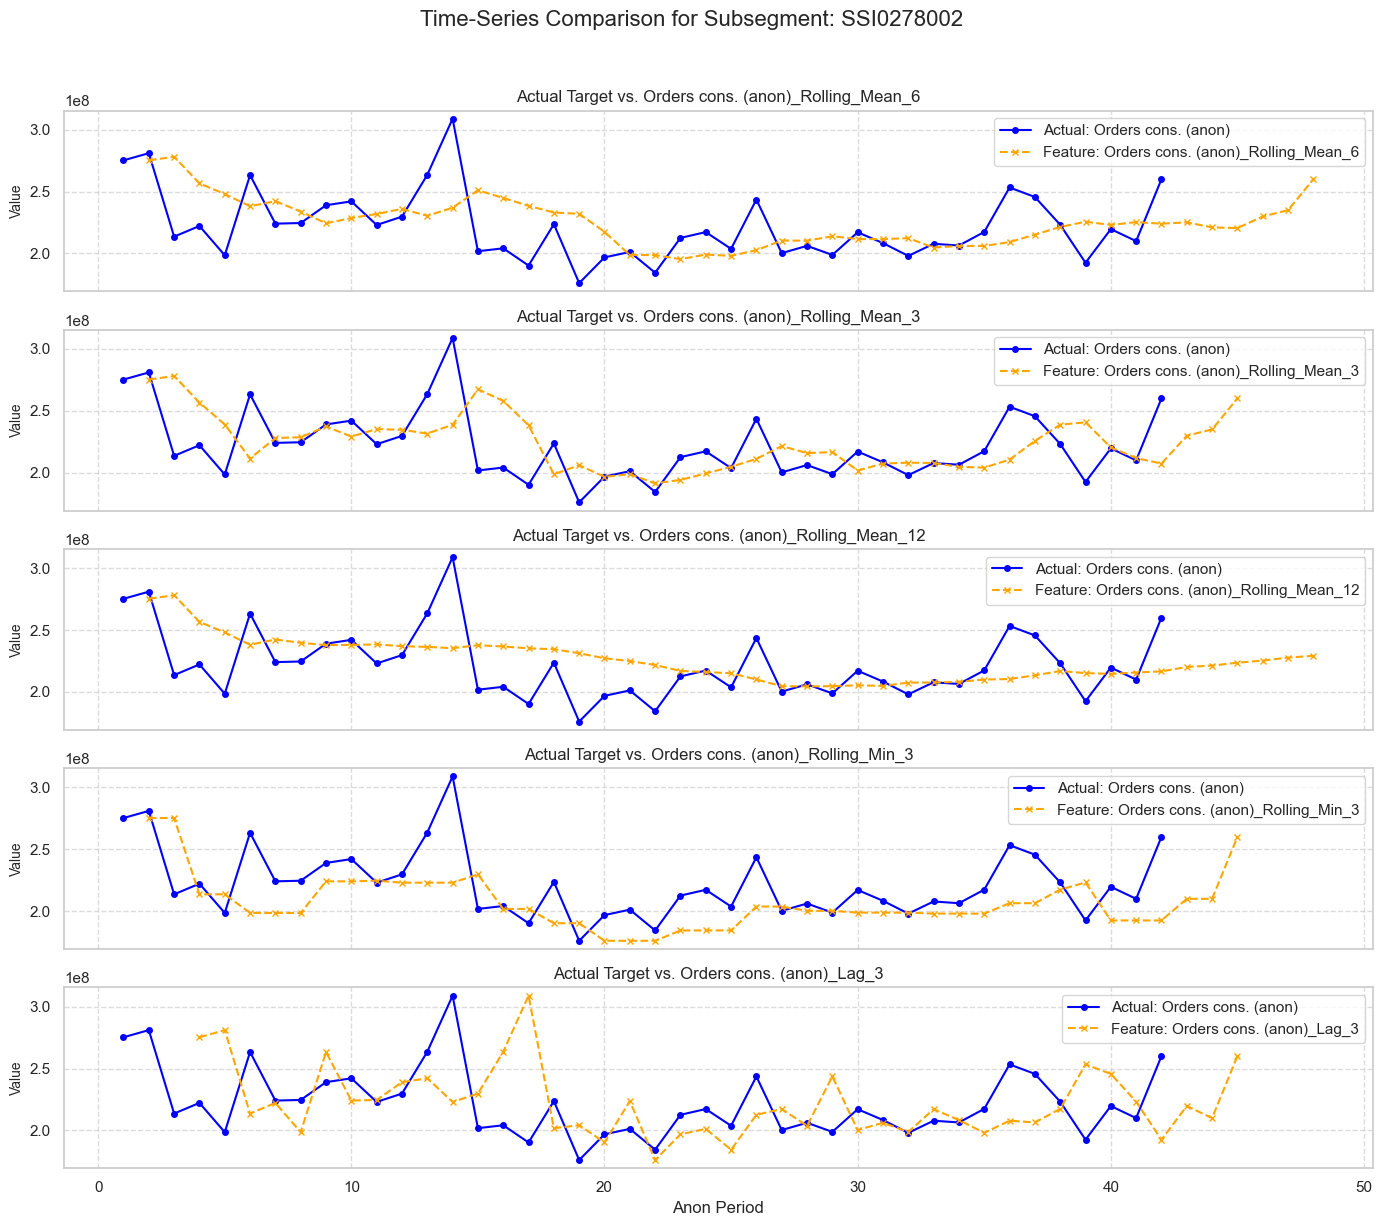

In [128]:
level_col = 'TGL Business Subsegment'
period_col = 'Anon Period'

# Identify the subsegment with the most records/highest volume in the dataset
top_subsegment = df[level_col].value_counts().idxmax()
print(f"Plotting Time-Series for the most frequent subsegment: {top_subsegment}")

# Filter data for this specific subsegment
sub_data = df[df[level_col] == top_subsegment].copy()

# Ensure chronological order
sub_data.sort_values(period_col, inplace=True)

# Select the top 5 features to plot against the target
top_5_features = top_15_features[:5]

# Create subplots
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 12), sharex=True)

for i, feature in enumerate(top_5_features):
    axes[i].plot(sub_data[period_col].values, sub_data[target_cols[0]].values, label=f'Actual: {target_cols[0]}', color='blue', marker='o', markersize=4)
    axes[i].plot(sub_data[period_col].values, sub_data[feature].values, label=f'Feature: {feature}', color='orange', linestyle='--', marker='x', markersize=4)
    axes[i].set_title(f'Actual Target vs. {feature}', fontsize=12)
    axes[i].set_ylabel('Value', fontsize=10)
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.7)

axes[-1].set_xlabel(period_col, fontsize=12)
plt.suptitle(f'Time-Series Comparison for Subsegment: {top_subsegment}', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## 4. Save Final Features Dataset
We split back into Train / Val to maintain pipeline boundaries, but now they possess all complex features correctly computed at the global scale!

In [129]:
# Drop Lag_24 — 62% missing, sinal coberto pelo Lag_12
cols_to_drop = [c for c in df.columns if '_Lag_24' in c]
df = df.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} Lag_24 columns.")

# Confirmar que o fix do period_macro está correto
macro_lag_cols = [c for c in df.columns if "_Lag_" in c and any(k in c for k in ["GDP", "Inflation"])]
macro_min = macro_df["Period"].min()

for col in macro_lag_cols:
    lag = int(col.split("_Lag_")[-1])
    safe_from = macro_min + lag
    bad = df[df["Anon Period"] >= safe_from][["Anon Period", col]].dropna(subset=[col], how="all")

    # períodos com NaN
    nan_periods = df[df["Anon Period"] >= safe_from][df[col].isna()]["Anon Period"].unique()

    if len(nan_periods) > 0:
        print(f"Make sense to have {col}: NaNs nos períodos {sorted(nan_periods)}")

print("Macro lag check done.")


Dropped 2 Lag_24 columns.
Macro lag check done.


In [130]:
# Categoricals mapping for standard pipeline expectations
cat_cols = ['TGL Business Unit', 'TGL Business Segment', 'TGL Business Subsegment']
for col in cat_cols:
    df[col] = df[col].astype('category')

df_train_fe = df[df['is_train'] == True].drop(columns=['is_train'])
df_val_fe = df[df['is_train'] == False].drop(columns=['is_train'])

output_dir = '../data/features'
os.makedirs(output_dir, exist_ok=True)

df_train_fe.to_parquet(os.path.join(output_dir, 'training_subsegment_fe.parquet'), index=False)
df_val_fe.to_parquet(os.path.join(output_dir, 'validation_subsegment_fe.parquet'), index=False)

print("Exported.")

Exported.


In [131]:
pd.read_parquet(os.path.join(output_dir, 'training_subsegment_fe.parquet')).columns.to_list()

['Anon Period',
 'TGL Business Unit',
 'TGL Business Segment',
 'TGL Business Subsegment',
 'Orders cons. (anon)',
 'Revenue cons. (anon)',
 'China_Core_Inflation_Rate',
 'China_Exports',
 'China_GDP',
 'China_GDP_from_Construction',
 'China_GDP_from_Manufacturing',
 'China_Industrial_Production',
 'China_Industrial_Production_Mom',
 'China_Inflation_Rate',
 'China_Interest_Rate',
 'China_Steel_Production',
 'France_Core_Inflation_Rate',
 'France_Exports',
 'France_GDP',
 'France_GDP_from_Construction',
 'France_GDP_from_Manufacturing',
 'France_Industrial_Production',
 'France_Industrial_Production_Mom',
 'France_Inflation_Rate',
 'France_Interest_Rate',
 'France_Steel_Production',
 'Germany_Core_Inflation_Rate',
 'Germany_Exports',
 'Germany_GDP',
 'Germany_GDP_from_Construction',
 'Germany_GDP_from_Manufacturing',
 'Germany_Industrial_Production',
 'Germany_Industrial_Production_Mom',
 'Germany_Inflation_Rate',
 'Germany_Interest_Rate',
 'Germany_Steel_Production',
 'Italy_Core_Infl

In [132]:
pd.read_parquet(os.path.join(output_dir, 'training_subsegment_fe.parquet')).head()

,Anon Period,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Orders cons. (anon),Revenue cons. (anon),China_Core_Inflation_Rate,China_Exports,China_GDP,China_GDP_from_Construction,...,United_States_Inflation_Rate_Lag_6,United_States_Inflation_Rate_Lag_12,United_States_Inflation_Rate_Rolling_Mean_3,United_States_Inflation_Rate_Rolling_Std_3,United_States_Inflation_Rate_Rolling_Mean_12,United_States_Inflation_Rate_Rolling_Std_12,United_States_Inflation_Rate_YoY_Diff,United_States_Inflation_Rate_YoY_Ratio,United_States_Inflation_Rate_Momentum_3_12,United_States_Inflation_Rate_Anomaly_12
0,1,SSI027,SSI02710,SSI02710,0.0,-390277.0,0.7,263.09,18201.7,32730.0,...,1.2,0.3,1.900000,0.624500,1.183333,0.657590,2.3,8.666667,0.716667,2.154332
1,2,SSI027,SSI02710,SSI02710,0.0,334.0,0.9,263.23,18201.7,32730.0,...,1.2,0.1,2.833333,1.266228,1.508333,1.036128,4.1,42.000000,1.325000,2.597814
2,3,SSI027,SSI02710,SSI02710,0.0,334.0,0.9,280.30,18201.7,32730.0,...,1.4,0.6,3.933333,1.222020,1.916667,1.348961,4.4,8.333333,2.016667,2.285709
3,4,SSI027,SSI02710,SSI02710,0.0,1811758.0,1.3,281.28,18201.7,53544.1,...,1.4,1.0,4.866667,0.611010,2.316667,1.609536,4.4,5.400000,2.550000,1.915666
4,5,SSI027,SSI02710,SSI02710,0.0,80112.0,1.2,293.17,18201.7,53544.1,...,1.7,1.3,5.266667,0.230940,2.683333,1.774995,4.1,4.153846,2.583333,1.530521


In [133]:
def missing_summary(df):
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    pct = (missing / len(df) * 100).round(2)
    return pd.DataFrame({"missing": missing, "pct": pct})

missing_summary(df_train_fe)

,missing,pct
ASP_YoY_Diff,1598,37.72
Orders cons. (anon)_YoY_Ratio,1578,37.24
ASP_Lag_12,1578,37.24
Revenue cons. (anon)_YoY_Ratio,1541,36.37
Orders cons. (anon)_Share_of_Parent_YoY_Diff_TGL Business Unit__TGL Business Segment,1509,35.61
...,...,...
Revenue cons. (anon)_Parent_Lag_1_TGL Business Unit,92,2.17
Revenue cons. (anon)_Parent_Rolling_Mean_6_TGL Business Unit,92,2.17
Revenue cons. (anon)_Parent_Rolling_Mean_3_TGL Business Unit,92,2.17
Italy_Inflation_Rate_YoY_Ratio,92,2.17


## 5. Final note on `NaN` values and their admissibility

The presence of missing values in the engineered dataset is largely **expected** and **admissible** given the nature of the time-series features created.

### Why these `NaN` values appear

Most engineered variables depend on past information. Therefore, missing values naturally arise when the required historical depth is not yet available. This happens especially in:

- **Lag features** such as `Lag_1`, `Lag_12`, and `Lag_24`:  
  These require 1, 12, or 24 previous periods, respectively. For the first observations of each time series, these values cannot be computed.

- **Year-over-Year features** such as `YoY_Diff` and `YoY_Ratio`:  
  These depend on values observed 12 periods earlier, so they are undefined when that history does not exist.

- **Rolling statistics** such as rolling means and rolling standard deviations:  
  These require a minimum number of prior observations. In particular, rolling standard deviations are undefined at the beginning of the series when there are too few points.

- **Ratio-based features** such as ASP or share-of-parent variables:  
  These may also become `NaN` when the denominator is zero or missing. In these cases, assigning `NaN` is preferable to forcing an invalid numerical value.

### Why these missing values are admissible

These missing values do **not** indicate a data-processing failure. Instead, they reflect the mathematical definition of the features:

- a lag cannot exist before enough past periods are available;
- a YoY comparison cannot be computed without a valid observation from 12 months earlier;
- a ratio should remain missing when its denominator is zero or undefined.

For this reason, the observed `NaN` values are considered **structurally valid** and are an inherent consequence of leakage-safe feature engineering in temporal data.

### Validation of the missingness pattern

- longer-memory features have more missing values than shorter-memory ones;
- YoY features are at least as sparse as 12-lag features;
- ratio features are slightly more sparse because they additionally depend on valid denominators.

This behavior is exactly what should be expected from correctly computed time-series features.

### Final conclusion

The remaining `NaN` values are therefore **admissible and expected**, rather than evidence of incorrect computation. They result from:

1. insufficient historical depth for some series;
2. rolling-window requirements;
3. undefined ratios due to zero or missing denominators.

These missing values should be handled at the modeling stage through an appropriate strategy, such as:
- keeping them when the selected model can handle missingness directly, OR
- imputing them in a controlled and leakage-safe way inside the modeling pipeline.

In summary, the current missingness pattern is acceptable and consistent with the feature engineering design.